# ✈️ Aviation Disasters Analysis
> End-to-end analysis of global aviation accidents — fatality patterns, high-risk operators, and the measurable impact of 9/11.


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
OUTPUT_DIR = r'C:\Users\Abderrahmane\aviation-disasters-analysis\outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

file_url = 'https://proai-datasets.s3.eu-west-3.amazonaws.com/aviation-accidents.csv'
df = pd.read_csv(file_url)
print(f'Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head()

Dataset loaded: 23,967 rows, 9 columns


,date,type,registration,operator,fatalities,location,country,cat,year
0,date unk.,Antonov An-12B,T-1206,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
1,date unk.,Antonov An-12B,T-1204,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
2,date unk.,Antonov An-12B,T-1201,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
3,date unk.,Antonov An-12BK,NaN,Soviet AF,NaN,Tiksi Airport (IKS),Russia,A1,unknown
4,date unk.,Antonov An-12BP,CCCP-11815,Soviet AF,0,Massawa Airport ...,Eritrea,A1,unknown


## 2. Data Cleaning

In [2]:
print('Missing values before cleaning:')
print(df.isnull().sum())
print(f'\nDuplicates: {df.duplicated().sum()}')

Missing values before cleaning:
date               0
type               0
registration    1548
operator           4
fatalities      3938
location         948
country            0
cat                0
year               0
dtype: int64

Duplicates: 115


In [3]:
# Fix fatalities column
df['fatalities'] = df['fatalities'].apply(lambda x: eval(x) if pd.notna(x) else 0)

# Remove rows with critical missing values
df = df.dropna(subset=['registration', 'location', 'operator'])

# Fix date column
df['date'] = df['date'].replace('date unk.', pd.NaT)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year_from_date'] = df['date'].dt.year
df.loc[df['date'].isna(), 'date'] = pd.to_datetime(
    df.loc[df['date'].isna(), 'year'].astype(str), format='%Y', errors='coerce'
)
df = df.drop(columns=['year_from_date'])
df = df.dropna(subset=['date'])

# Add time features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_week'] = df['date'].dt.dayofweek
df['decade'] = (df['year'] // 10) * 10

print(f'\nClean dataset: {df.shape[0]:,} rows')
print('Missing values after cleaning:')
print(df.isnull().sum())


Clean dataset: 21,540 rows
Missing values after cleaning:
date            0
type            0
registration    0
operator        0
fatalities      0
location        0
country         0
cat             0
year            0
month           0
day_week        0
decade          0
dtype: int64


## 3. Exploratory Analysis

In [4]:
# Key metrics
total_accidents = len(df)
total_fatalities = int(df['fatalities'].sum())
avg_fatalities = df['fatalities'].mean()
deadliest_year = df.groupby('year')['fatalities'].sum().idxmax()
most_accidents_country = df['country'].value_counts().idxmax()

print('=' * 50)
print('   KEY METRICS')
print('=' * 50)
print(f'  Total accidents:      {total_accidents:,}')
print(f'  Total fatalities:     {total_fatalities:,}')
print(f'  Avg fatalities/acc:   {avg_fatalities:.2f}')
print(f'  Deadliest year:       {deadliest_year}')
print(f'  Most accidents:       {most_accidents_country}')
print('=' * 50)

   KEY METRICS
  Total accidents:      21,540
  Total fatalities:     128,435
  Avg fatalities/acc:   5.96
  Deadliest year:       2001
  Most accidents:       USA


## 4. Visualizations

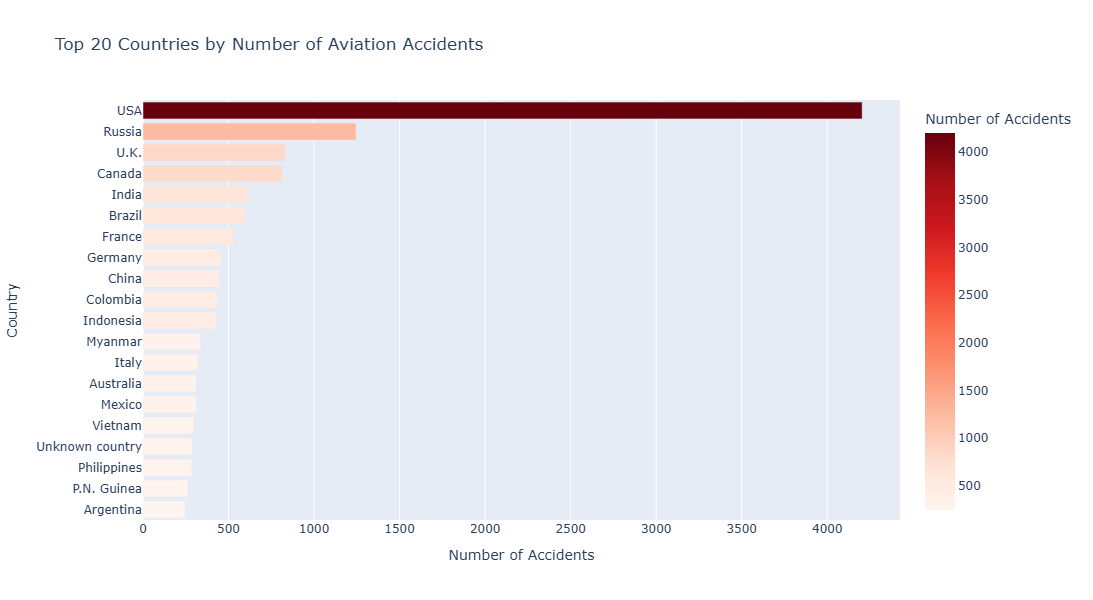

In [5]:
# --- Chart 1: Top 20 Countries (interactive) ---
accidents_by_country = df['country'].value_counts().reset_index()
accidents_by_country.columns = ['country', 'accidents']
top20 = accidents_by_country.head(20)

fig = px.bar(
    top20, x='accidents', y='country', orientation='h',
    title='Top 20 Countries by Number of Aviation Accidents',
    color='accidents', color_continuous_scale='Reds',
    labels={'accidents': 'Number of Accidents', 'country': 'Country'}
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.show()
fig.write_image(f'{OUTPUT_DIR}\\accidents_by_country.png', scale=2)

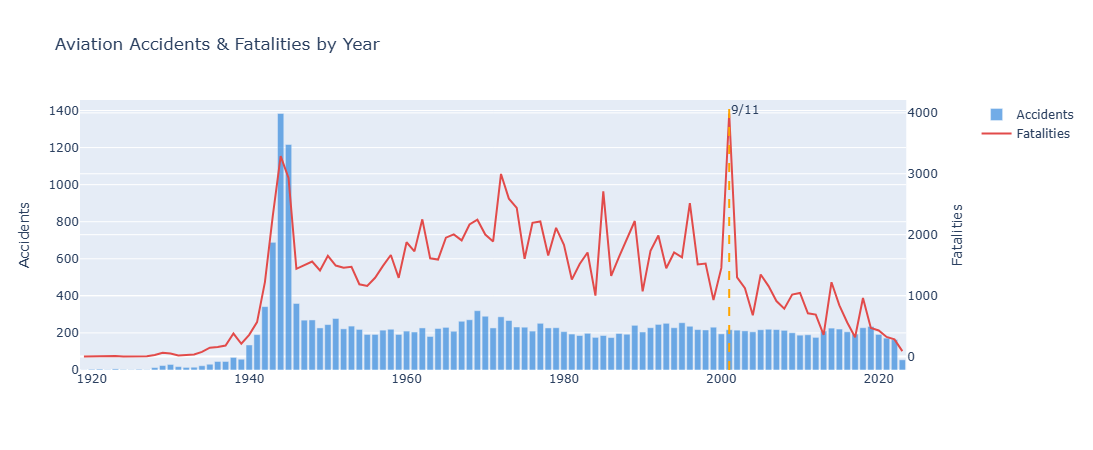

In [6]:
# --- Chart 2: Accidents & Fatalities by Year (interactive) ---
yearly = df.groupby('year').agg(
    accidents=('date', 'count'),
    fatalities=('fatalities', 'sum')
).reset_index()

fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Bar(x=yearly['year'], y=yearly['accidents'],
                     name='Accidents', marker_color='#378ADD', opacity=0.7), secondary_y=False)
fig.add_trace(go.Scatter(x=yearly['year'], y=yearly['fatalities'],
                         name='Fatalities', line=dict(color='#E24B4A', width=2),
                         mode='lines'), secondary_y=True)
fig.add_vline(x=2001, line_dash='dash', line_color='orange',
              annotation_text='9/11', annotation_position='top right')
fig.update_layout(title='Aviation Accidents & Fatalities by Year', height=450)
fig.update_yaxes(title_text='Accidents', secondary_y=False)
fig.update_yaxes(title_text='Fatalities', secondary_y=True)
fig.show()
fig.write_image(f'{OUTPUT_DIR}\\accidents_by_year.png', scale=2)

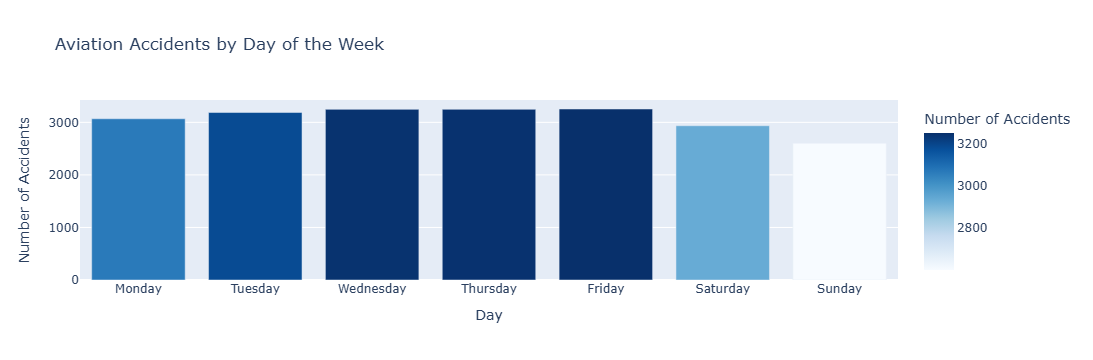

In [7]:
# --- Chart 3: Accidents by Day of Week ---
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
accidents_by_day = df.groupby('day_week').size().reset_index(name='accidents')
accidents_by_day['day_name'] = accidents_by_day['day_week'].map(dict(enumerate(days)))

fig = px.bar(
    accidents_by_day, x='day_name', y='accidents',
    title='Aviation Accidents by Day of the Week',
    color='accidents', color_continuous_scale='Blues',
    labels={'day_name': 'Day', 'accidents': 'Number of Accidents'}
)
fig.update_layout(xaxis={'categoryorder': 'array', 'categoryarray': days})
fig.show()
fig.write_image(f'{OUTPUT_DIR}\\accidents_by_day.png', scale=2)

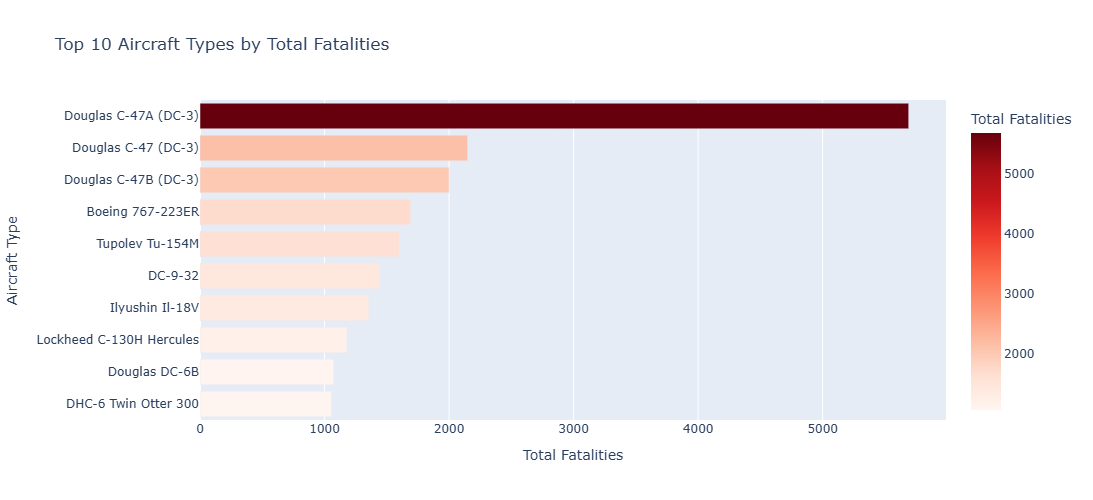

In [8]:
# --- Chart 4: Top 10 Aircraft Types by Fatalities ---
type_fatalities = df.groupby('type')['fatalities'].sum().nlargest(10).reset_index()

fig = px.bar(
    type_fatalities, x='fatalities', y='type', orientation='h',
    title='Top 10 Aircraft Types by Total Fatalities',
    color='fatalities', color_continuous_scale='Reds',
    labels={'fatalities': 'Total Fatalities', 'type': 'Aircraft Type'}
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=500)
fig.show()
fig.write_image(f'{OUTPUT_DIR}\\aircraft_fatalities.png', scale=2)

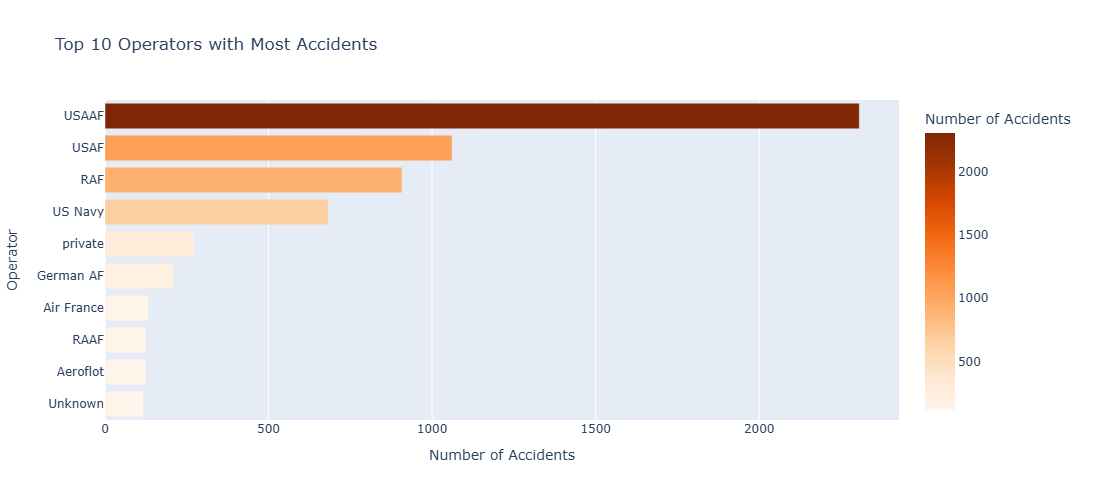

In [9]:
# --- Chart 5: Top 10 Operators ---
top_operators = df['operator'].value_counts().head(10).reset_index()
top_operators.columns = ['operator', 'accidents']

fig = px.bar(
    top_operators, x='accidents', y='operator', orientation='h',
    title='Top 10 Operators with Most Accidents',
    color='accidents', color_continuous_scale='Oranges',
    labels={'accidents': 'Number of Accidents', 'operator': 'Operator'}
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=500)
fig.show()
fig.write_image(f'{OUTPUT_DIR}\\accidents_by_operator.png', scale=2)

## 5. The 9/11 Effect

   THE 9/11 EFFECT ON AVIATION FATALITIES
  Avg fatalities BEFORE 9/11:  6.33
  Avg fatalities AFTER 9/11:   4.54
  Reduction:                   28.3%


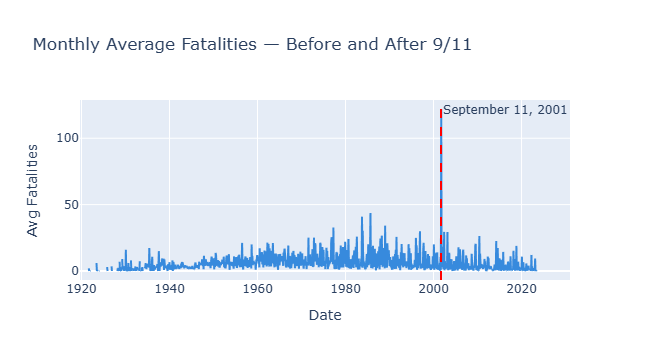

In [11]:
pre_911 = df[df['date'] < '2001-09-11']
post_911 = df[df['date'] >= '2001-09-11']

mean_pre = pre_911['fatalities'].mean()
mean_post = post_911['fatalities'].mean()
reduction = ((mean_pre - mean_post) / mean_pre) * 100

print('=' * 55)
print('   THE 9/11 EFFECT ON AVIATION FATALITIES')
print('=' * 55)
print(f'  Avg fatalities BEFORE 9/11:  {mean_pre:.2f}')
print(f'  Avg fatalities AFTER 9/11:   {mean_post:.2f}')
print(f'  Reduction:                   {reduction:.1f}%')
print('=' * 55)

# Timeline chart
daily = df.set_index('date')['fatalities'].resample('ME').mean().reset_index()

fig = px.line(
    daily, x='date', y='fatalities',
    title='Monthly Average Fatalities — Before and After 9/11',
    labels={'date': 'Date', 'fatalities': 'Avg Fatalities'}
)
fig.add_vline(x=pd.Timestamp('2001-09-11').timestamp() * 1000, line_dash='dash', line_color='red',
              annotation_text='September 11, 2001',
              annotation_position='top right')
fig.update_traces(line_color='#378ADD')
fig.show()
fig.write_image(f'{OUTPUT_DIR}\\sept11_impact.png', scale=2)

## 6. Correlation Analysis

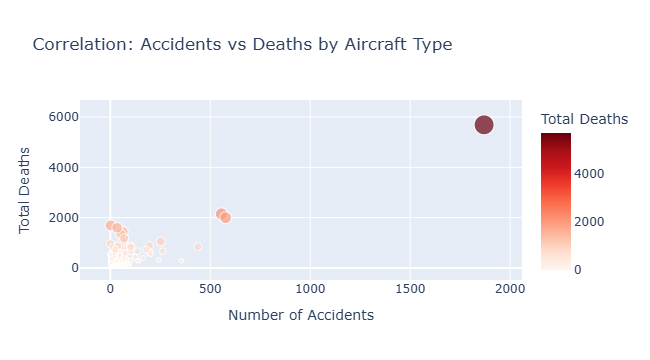

In [12]:
# Accidents vs Deaths scatter
accidents_type = df.groupby('type').size().reset_index(name='accidents')
deaths_type = df.groupby('type')['fatalities'].sum().reset_index(name='deaths')
analysis = pd.merge(accidents_type, deaths_type, on='type')

fig = px.scatter(
    analysis, x='accidents', y='deaths',
    hover_name='type', size='deaths', color='deaths',
    color_continuous_scale='Reds',
    title='Correlation: Accidents vs Deaths by Aircraft Type',
    labels={'accidents': 'Number of Accidents', 'deaths': 'Total Deaths'}
)
fig.show()
fig.write_image(f'{OUTPUT_DIR}\\correlation_scatter.png', scale=2)

## 7. World Map

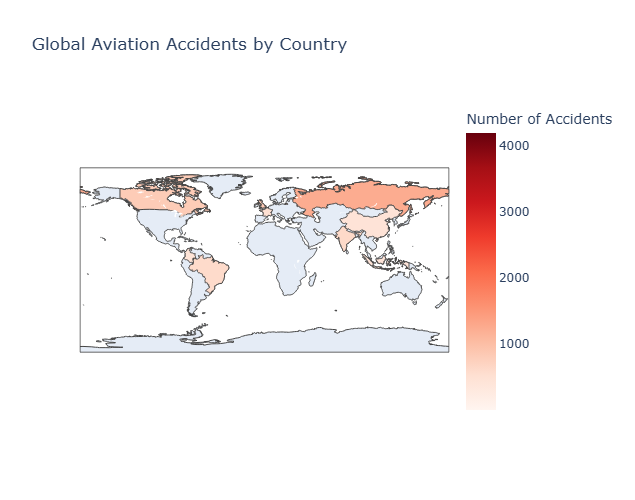

In [13]:
# Interactive world map with Plotly (no shapefile needed)
country_mapping = {
    'United States': 'USA',
    'U.K.': 'GBR',
    'Russia': 'RUS',
    'Brazil': 'BRA',
    'France': 'FRA',
    'Colombia': 'COL',
    'Canada': 'CAN',
    'India': 'IND',
    'Indonesia': 'IDN',
    'China': 'CHN'
}

map_data = accidents_by_country.copy()
map_data['iso'] = map_data['country'].map(country_mapping)

fig = px.choropleth(
    map_data, locations='iso',
    color='accidents',
    hover_name='country',
    color_continuous_scale='Reds',
    title='Global Aviation Accidents by Country',
    labels={'accidents': 'Number of Accidents'}
)
fig.update_layout(height=500)
fig.show()
fig.write_image(f'{OUTPUT_DIR}\\world_map.png', scale=2)

## 8. Executive Summary

In [14]:
print('=' * 55)
print('   EXECUTIVE SUMMARY — AVIATION DISASTERS ANALYSIS')
print('=' * 55)
print(f'  Total accidents:         {total_accidents:,}')
print(f'  Total fatalities:        {total_fatalities:,}')
print(f'  Most dangerous country:  {most_accidents_country}')
print(f'  Deadliest year:          {deadliest_year}')
print(f'  Fatality reduction after 9/11: {reduction:.1f}%')
print()
print('  RECOMMENDATIONS:')
print('  1. Focus safety audits on top 5 operators with most accidents')
print('  2. Stricter maintenance for high-fatality aircraft types')
print('  3. Post-9/11 security measures proved effective — expand globally')
print('=' * 55)

   EXECUTIVE SUMMARY — AVIATION DISASTERS ANALYSIS
  Total accidents:         21,540
  Total fatalities:        128,435
  Most dangerous country:  USA
  Deadliest year:          2001
  Fatality reduction after 9/11: 28.3%

  RECOMMENDATIONS:
  1. Focus safety audits on top 5 operators with most accidents
  2. Stricter maintenance for high-fatality aircraft types
  3. Post-9/11 security measures proved effective — expand globally
